# Unit Test Notebook for Gripper class functions

In [1]:
import asyncio
import sys
import time
sys.path.append('../')
sys.path.append('../../')
import numpy as np
import magpie_control.gripper as g
from magpie_control.gripper import Gripper

import magpie_control.ur5 as u
from magpie_control import ur5
import importlib
importlib.reload(g)
importlib.reload(u)

<module 'magpie_control.ur5' from '/home/will/workspace/magpie_control/src/magpie_control/ur5.py'>

In [2]:
servoport = '/dev/ttyACM0'
G = Gripper(servoport=servoport, debug=False)

r = ur5.UR5_Interface(robotIP="192.168.0.4")
r.start()

r.start_ft_sensor(ip_address="192.168.0.5", poll_rate=100)
print(f"{r.get_ft_data()=}")

Succeeded to open the port
Succeeded to change the baudrate
r.get_ft_data()=[0.0, 0.0, 0.4, -0.008, 0.013, 0.001]


In [5]:
r.toggle_teach_mode()

In [3]:
async def reset_and_close_gripper(gripper, force_limit=2, duration=-1):
    def close_gripper(g, force=2):
        g.reset_packet_overload(force_limit=force_limit)
        g.close_gripper()
    start = time.time()
    if duration < 0:
        close_gripper(gripper, force=force_limit)
        return
    while time.time() - start < duration:
        close_gripper(gripper, force=force_limit)
        await asyncio.sleep(0.25)

# rotation matrix with -1, 1, -1 on diagonal
def orient_TCP_down(r):
    """orient TCP facing down toward the table, z-axis down"""
    R = np.array([[-1, 0, 0], [0, 1, 0], [0, 0, -1]])
    p = np.array(r.getPose())
    p[:3, :3] = R
    r.moveL(p)

import matplotlib.pyplot as plt

def plot_cf_ft(cf, ft, plot_cf=True, plot_ft=True):
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    if plot_cf:
        cf = np.array(cf)
        ax1.plot(cf[:, 0], label='left')
        ax1.plot(cf[:, 1], label='right')
        ax1.set_title("Finger Contact Forces")
        ax1.legend()
    if plot_ft:
        ft = np.array(ft)
        ax2.plot(ft[:, 0], label='fx')
        ax2.plot(ft[:, 1], label='fy')
        ax2.plot(ft[:, 2], label='fz')
        # plt.plot(ft[:, 3], label='tx')
        # plt.plot(ft[:, 4], label='ty')
        # plt.plot(ft[:, 5], label='tz')
        ax2.set_title("Wrist Forces")
        ax2.legend()
    fig.tight_layout()
    plt.show()

# orient_TCP_down(r)
await reset_and_close_gripper(G, force_limit=20)

In [9]:
import rerun as rr
rr.init("force tracking", spawn=True)

rr.log("finger/left",
       rr.SeriesPoint(
        color=[255, 0, 0],
        name="Left Finger Contact Force",
        marker="circle",
        marker_size=4,
       ),
       static=True
       )

rr.log("finger/right",
       rr.SeriesPoint(
        color=[0, 255, 0],
        name="Right Finger Contact Force",
        marker="circle",
        marker_size=2,
       ),
       static=True
       )

def rr_log_vectors(name, vector, origins, color=[0, 0, 255], label="wrist forces"):
    rr.log(f"wrist/{name}",
       rr.Arrows3D(
        vectors=vector,
        origins=origins,
        labels=[label],
        colors=color,
        radii=0.03,
       ),
       static=True,
    )

start = time.time()
t = 0
ft = []
x, y, z, origins = [], [], [], []
r.start_ft_sensor()
time.sleep(0.5)
rr.set_time_seconds("time", time.time())
while time.time() - start < 20:
# while True:
    rr.set_time_sequence("step", t)
    t += 1
    cf = G.interval_force_measure(G.latency, 5, finger='both', distinct=True)
    await G.reset_and_close_gripper(force_limit=10)
    pos = np.array(r.getPose())[:3, 3]*100
    force = r.get_ft_data()[:3]
    origins.append(pos)
    ft.append(force if len(force) == 3 else [0, 0, 0])
    x.append([force[0], 0, 0])
    y.append([0, force[1], 0])
    z.append([0, 0, force[2]])
    rr_log_vectors("x", x, origins, color=[255, 0, 0], label="fx")
    rr_log_vectors("y", y, origins, color=[0, 255, 0], label="fy")
    rr_log_vectors("z", z, origins, color=[0, 0, 255], label="fz")
#     rr_log_vectors("xyz", ft, color=[0, 0, 0], label="ft")
    rr.log("finger/left", rr.Scalar(cf[0]))
    rr.log("finger/right", rr.Scalar(cf[1]))
    time.sleep(0.05)

[2025-04-04T22:24:51Z INFO  re_sdk_comms::server] Hosting a SDK server over TCP at 0.0.0.0:9876. Connect with the Rerun logging SDK.
[2025-04-04T22:24:51Z INFO  winit::platform_impl::linux::x11::window] Guessed window scale factor: 1
[2025-04-04T22:24:51Z INFO  re_sdk_comms::server] New SDK client connected from: 127.0.0.1:40226
[2025-04-04T22:24:51Z WARN  wgpu_hal::gles::egl] No config found!
[2025-04-04T22:24:51Z WARN  wgpu_hal::gles::egl] EGL says it can present to the window but not natively
[2025-04-04T22:24:51Z WARN  wgpu_hal::gles::adapter] Max vertex attribute stride unknown. Assuming it is 2048
[2025-04-04T22:24:51Z WARN  wgpu_hal::gles::adapter] Max vertex attribute stride unknown. Assuming it is 2048
[2025-04-04T22:24:51Z INFO  egui_wgpu] There were 3 available wgpu adapters: {backend: Vulkan, device_type: DiscreteGpu, name: "NVIDIA GeForce RTX 2070", driver: "NVIDIA", driver_info: "550.120", vendor: 0x10DE, device: 0x1F02}, {backend: Vulkan, device_type: Cpu, name: "llvmpip

Error reading from OptoForce!


IndexError: list index out of range

In [47]:
ft

[[0.6, -0.3, -1.3],
 [-0.6, -0.7, -0.7],
 [-0.6, -0.7, -1.4],
 [-0.5, -0.7, -0.3],
 [-0.5, -0.7, -1.7],
 [-0.6, -0.8, -1.9],
 [-0.5, -0.7, -0.4],
 [-0.6, -0.7, -1.0],
 [-0.5, -0.8, -1.0],
 [-0.3, -0.8, -0.3],
 [-0.5, -0.8, -0.9],
 [-0.5, -0.9, -1.7],
 [0.1, -0.7, -0.6],
 [],
 [2.4, -0.5, 0.0],
 [1.8, -1.0, 0.6],
 [1.2, -0.5, 0.8],
 [3.2, -0.1, 0.3],
 [0.7, -1.0, -0.8],
 [-5.3, -1.7, -2.6],
 [-7.4, -1.9, -5.8],
 [-11.2, -2.5, -7.2],
 [-11.2, -2.6, -6.5],
 [-8.4, -1.9, -5.7],
 [-9.6, -3.1, -4.0],
 [-6.9, -1.4, -2.9],
 [-7.1, -1.5, -2.6],
 [-7.7, -1.4, -1.7],
 [-8.0, -1.5, -2.0],
 [-8.6, -0.1, -1.6],
 [-7.9, -0.7, -1.0],
 [-6.1, 0.1, -2.0],
 [-4.2, 2.3, -1.3],
 [-6.1, 1.5, -2.4],
 [-5.6, 1.5, -2.9],
 [-3.3, 3.1, -1.3],
 [-5.2, 0.0, -3.7],
 [-2.1, 0.9, -3.3],
 [-1.3, -0.4, -1.4],
 [-1.1, 0.6, -0.9],
 [-0.5, 1.1, -1.6],
 [-0.5, 1.1, -1.1],
 [-0.5, 0.9, -0.7],
 [-0.5, 0.6, -2.4],
 [-0.2, 0.9, 0.0],
 [0.5, 1.1, 1.1],
 [0.8, 1.1, -1.4],
 [2.6, 2.0, 0.2],
 [3.7, 0.9, 1.0],
 [4.2, 1.9, 1.4],
 [6

In [32]:
rr.datatypes.Vec3D

rerun.datatypes.vec3d.Vec3D

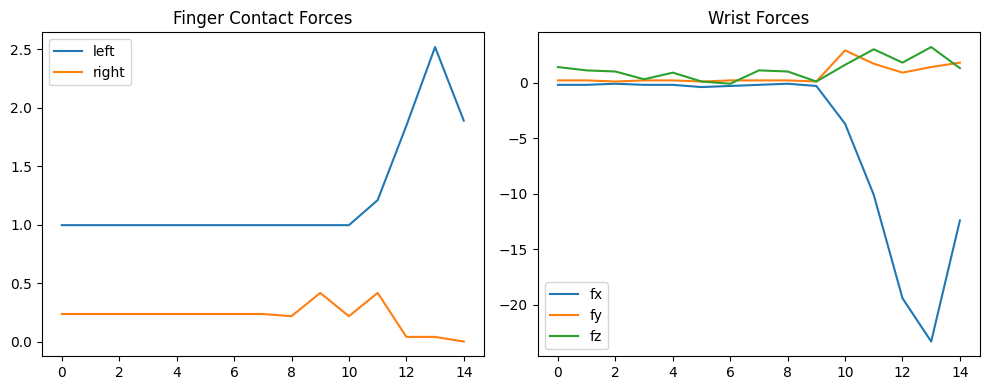

In [43]:
cf = []
ft = []
# await cam.stop_record()
# await record(5)
# cam.begin_record(filepath='record/workspace/')
start = time.time()
# await record(10)
# await reset_and_close_gripper(G, duration=5)
while time.time() - start < 2:
    cf.append([G.interval_force_measure(G.latency, 5, finger='right'), 
               G.interval_force_measure(G.latency, 5, finger='left')])
    ft.append(r.get_ft_data())
    await reset_and_close_gripper(G)
    # time.sleep(0.05)
# await cam.stop_record()
plot_cf_ft(cf, ft)

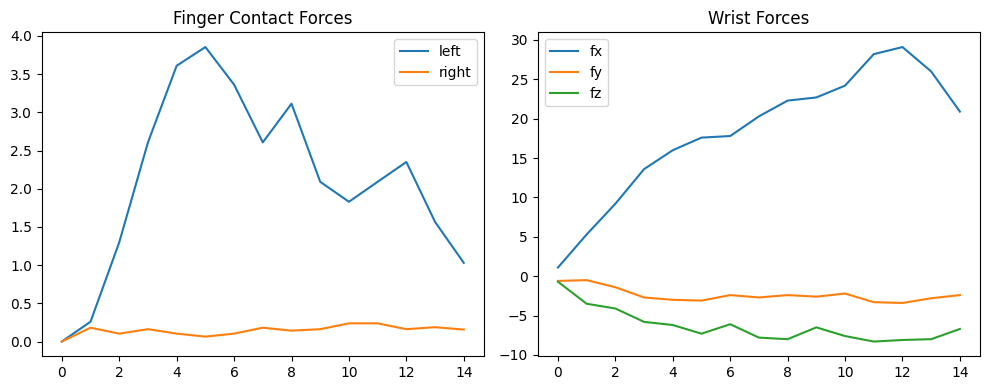